In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

# from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
from xgboost import XGBRegressor, XGBRFRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import SGDRegressor
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import root_mean_squared_log_error
import matplotlib.pyplot as plt


TARGET = 'Calories'
USED_COLUMNS = ['']

# load dataetition dataset
comp = pd.read_csv('data/train.csv', index_col='id').astype({'Sex': 'category', 'Age': 'float64'})
# load original dataset
orig = pd.read_csv('data/calories.csv', index_col='User_ID').rename(columns={'Gender': 'Sex'}).astype({'Sex': 'category'})
# concatenate
df = pd.concat([comp, orig]).reset_index(drop=True)

# load test part
test = pd.read_csv('data/test.csv', index_col='id').astype({'Sex': 'category', 'Age': 'float64'})
test[TARGET] = 0

In [2]:
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36.0,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64.0,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51.0,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20.0,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38.0,166.0,61.0,25.0,102.0,40.6,146.0


In [3]:
def checkup(estimator_base, X, y, folds=7, scaler=None, clip=(-np.inf, np.inf)):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict(X.loc[train])
        pv = estimator.predict(X.loc[valid])

        if scaler:
            RMSLE_train = root_mean_squared_log_error(
                scaler.inverse_transform(y[train].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pt.reshape(-1, 1)), *clip)[:, 0]
            )
            RMSLE_valid = root_mean_squared_log_error(
                scaler.inverse_transform(y[valid].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pv.reshape(-1, 1)), *clip)[:, 0]
            )
        else:
            RMSLE_train = root_mean_squared_log_error(y[train], np.clip(pt, *clip))
            RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(pv, *clip))

        metrics.append((RMSLE_train, RMSLE_valid))
        print(f'Fold: {f}; TRAIN RMSLE={RMSLE_train:.5f}; | VALID RMSLE={RMSLE_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN RMSLE={means[0]:.5f}; | VALID RMSLE={means[1]:.5f}')
    return estimator

In [4]:
# df.Age.unique().size, test.Age.unique().size
# df.Duration.unique().size, test.Duration.unique().size
# df.Weight.unique().size, test.Weight.unique().size
# df.Height.unique().size, test.Height.unique().size

__Feature engineering__

In [5]:
NPCA = 3
GPCA = 15
# FPCA = 20
ORIGIN = df.columns.to_list()
ORIGIN.remove('Calories')

pipe = make_pipeline(
    # Recast categories
    # Calc('Sex.cat.codes', to='Sex'),
    Calc('(Sex == "male").astype(int)', to='Sex'),

    # Body-mass index
    # Calc('Weight / (Height / 100) ** 2', to='BMI'),
    Calc('np.round(Weight / (Height / 100) ** 2, 1)', to='BMI'),  # for grouping

    Calc('Body_Temp / Duration', to='F1'),
    Calc('Weight / Heart_Rate', to='F2'),
    Calc('Weight / Duration', to='F3'),
    Calc('Heart_Rate / Duration', to='F4'),
    Calc('Heart_Rate / Body_Temp', to='F5'),
    Calc('Age / Weight', to='F6'),

    Calc('(Heart_Rate > 99.5).astype(int)', to='F7'),
    Calc('(Body_Temp > 39.5).astype(int)', to='F8'),
    Calc('(Age > 65).astype(int)', to='F9'),
    Calc(lambda row: row.Weight > (80 if row.Sex else 60), to='F10'),    # Female > 60, Male > 80

    Calc('Age / Heart_Rate', to='F11'),
    Calc('Age / Duration', to='F12'),
    Calc('Body_Temp * Duration', to='F13'),
    Calc('Heart_Rate * Duration', to='F14'),
    Calc('Age * Duration', to='F15'),
    Calc('Body_Temp - 36.9', to='F16'),

    # WTF
    Calc('np.log(Heart_Rate * Body_Temp / Duration)', to='F20'),
    Calc('np.log((Heart_Rate * Body_Temp * Duration * Age) ** (Weight / Height))', to='F21'),
    Calc('BMI * Age', to='F22'),

    # bins
    Bins('Age', to='ct_Age', bins=15, quantile=True),
    Bins('Duration', to='ct_Duration', bins=15, quantile=True),
    Bins('Weight', to='ct_Weight', bins=10, quantile=True),
    Bins('Height', to='ct_Height', bins=10, quantile=True),
    # Bins('BMI', to='ct_BMI', bins=[0, 16, 18.5, 25, 30, 35, 40, np.inf]),

    # apply estimators
    # Fill('mean'),
    # WithSelected(ORIGIN)(   # oPCA
    WithSelected(r'(?!F)')(   # ocPCA
    # # WithSelected(lambda x: True)(   # aPCA
    #     # Apply(PCA(n_components=NPCA, random_state=17), locpipe=pre.StandardScaler(), to=[f'PCA{n + 1}' for n in range(NPCA)]),
        Apply(PCA(n_components=NPCA, random_state=17), to=[f'PCA{n + 1}' for n in range(NPCA)]),    # nostd
    ),

    # Apply(KMeans(n_clusters=9, random_state=13), locpipe=pre.StandardScaler(), on=ORIGIN, to='KMeans'),     # oKMeans
    # Apply(KMeans(n_clusters=9, random_state=13), locpipe=pre.StandardScaler(), to='KMeans'),                # aKMeans
    # Apply(KMeans(n_clusters=7, random_state=13), to='KMeans'),      # aKMeans[nostd]
    # Group(['KMeans'], 'mean', prefix='mean_K_', target='include'), # G0
    # Group(['KMeans'], 'mean', prefix='mean_K_', target='exclude'), # G0

    # Polynomials
    WithSelected(ORIGIN, prefix='poly')(
        make_pipeline(
            pre.StandardScaler(),
            pre.PolynomialFeatures(degree=2)
        ),
    ),

    # group statistics
    # WithSelected(r'(?!mean_|ct_)')(
    WithSelected(r'(?!PCA|KMeans|mean_|poly_)')(
        Group('ct_Age', 'mean', prefix='mean_Age_', target='only'),                 # 1
        Group('ct_Duration', 'mean', prefix='mean_Duration_', target='only'),       # 2
        # Group('ct_Weight', 'mean', prefix='mean_Weight_', target='only'),           # 3
        # Group('ct_Height', 'mean', prefix='mean_Height_', target='only'),           # 4

        # Group(['Sex', 'ct_Age'], 'mean', prefix='mean_SexAge_', target='only'),             # 5
        # Group(['Sex', 'ct_Duration'], 'mean', prefix='mean_SexDuration_', target='only'),   # 6
        # Group(['ct_Age', 'ct_Duration'], 'mean', prefix='mean_AgeDuration_', target='only'),    # 7

        # Group(['Sex', 'ct_Weight'], 'mean', prefix='mean_SexWeight_', target='only'),       # 8
        # Group(['Sex', 'ct_Height'], 'mean', prefix='mean_SexHeight_', target='only'),                               # 9
        # Group(['ct_Weight', 'Duration'], 'mean', prefix='mean_WeightDuration_', target='only'),                     # 10
        # Group(['Sex', 'ct_Duration', 'ct_Weight'], 'median', prefix='median_SexDurationWeight_', target='only'),    # 11

        # Group(['Sex', 'ct_Duration', 'ct_Weight'], 'mean', prefix='mean_SexDurationWeight_', target='only'),                # 12
        # Group(['Sex', 'ct_Duration', 'ct_Height'], 'mean', prefix='mean_SexDurationHeight_', target='only'),                # 13
        # Group(['Sex', 'ct_Age', 'ct_Duration', 'ct_Weight'], 'mean', prefix='mean_SexAgeDurationWeight_', target='only'),   # 14
        # Group(['Sex', 'ct_Age', 'ct_Duration', 'ct_Height'], 'mean', prefix='mean_SexAgeDurationHeight_', target='only'),   # 15

        # Group(['Sex', 'ct_Age', 'BMI'], 'mean', prefix='mean_SexAgeBMI_', target='only'),               # 16
        # Group(['Sex', 'ct_Age', 'ct_Duration'], 'mean', prefix='mean_SexAgeDuration_', target='only'),  # 17
        # Group(['Sex', 'BMI'], 'mean', prefix='mean_SexBMI_', target='only'),             # 18
        # Group(['Sex', 'Duration'], 'mean', prefix='mean_SexDurationORI_', target='only'),   # 19

        # Group(['Sex', 'Age', 'Duration', 'Weight'], 'mean', prefix='mean_SexAgeDurationWeight_', target='exclude'),   # E1
        # Group(['Sex', 'Age', 'Duration', 'ct_Weight'], 'mean', prefix='mean_SexAgeDurationWeight_', target='only'),     # E2
        # Group(['Sex', 'ct_Age', 'ct_Weight'], 'mean', prefix='mean_SexAgeWeight_', target='exclude'),  # E3

        # Group(['ct_BMI'], 'mean', prefix='mean_ctBMI_', target='only'),             # E4
        # Group(['BMI'], 'mean', prefix='mean_ctBMI_', target='only'),             # E4.1
        Group(['BMI'], 'median', prefix='median_ctBMI_', target='only'),             # E4.2

        # Group(['BMI', 'Duration'], 'median', prefix='median_WTF1', target='only'),   # WTF

        # Group(['BMI', 'Duration'], 'median', prefix='median_WTF1', target='exclude'),   # WTF
        # Group(['ct_Age', 'ct_Duration'], 'mean', prefix='mean_WTF2', target='only'),   # WTF
        # Group(['Sex', 'ct_Age', 'BMI', 'ct_Duration'], 'mean', prefix='mean_WTF3', target='only'),  # WTF
        # Group(['Sex', 'BMI', 'ct_Age', 'Duration'], 'mean', prefix='mean_WTF3', target='only'),  # WTF
    ),
    # drop columns
    # Select(r'(?:mean_.*_ct_|ct_)', mode='drop'),
    # Select(['Sex', 'Age', 'Height'], mode='drop'),
    # Select(r'mean_|Sex|activity_index', mode='keep'),
    # Select(ORIGIN, mode='drop'),    # -O

    # fill NaN
    Fill('mean'),

    # compress means with PCA
    # WithSelected(r'mean_')(
    #     # Apply(PCA(n_components=GPCA, random_state=29), locpipe=pre.StandardScaler(), to=[f'gPCA{n + 1}' for n in range(GPCA)]),
    #     Apply(PCA(n_components=GPCA, random_state=29), to=[f'gPCA{n + 1}' for n in range(GPCA)]),   # nostd
    # ),
    # Select(r'mean_', mode='drop'),

    # compress all with PCA
    # WithSelected(r'(?!PCA)')(
    #     # Apply(PCA(n_components=GPCA, random_state=29), locpipe=pre.StandardScaler(), to=[f'gPCA{n + 1}' for n in range(GPCA)]),
        # Apply(PCA(n_components=GPCA, random_state=29), to=[f'gPCA{n + 1}' for n in range(GPCA)]),   # nostd
    # ),
    # Select(r'(?!gPCA|PCA)', mode='drop'),

    # final PCA
    # Apply(PCA(n_components=FPCA, random_state=29), locpipe=pre.StandardScaler(), to=[f'fPCA{n + 1}' for n in range(FPCA)]),    # fPCA
    # Select(lambda col: col.startswith('fPCA') or col in ORIGIN, mode='keep'),

    # standardize & power
    # KeepDataframe(make_pipeline(
    #     # pre.QuantileTransformer(random_state=17),
    #     # pre.PowerTransformer(standardize=True),
    #     pre.StandardScaler(),
    #     pre.PowerTransformer(standardize=False),
    #     # pre.MinMaxScaler(),
    #     # pre.StandardScaler(),
    #     # pre.RobustScaler(),
    # )),

    WithSelected(r'(?!poly_)')(
        KeepDataframe(make_pipeline(
            pre.StandardScaler(),
            pre.PowerTransformer(standardize=False),
        )),
    )
)
y_pipe = pre.PowerTransformer()

X: pd.DataFrame = pipe.fit_transform(df.drop(columns=TARGET), df[TARGET])     # type: ignore
y = y_pipe.fit_transform(df[TARGET].to_numpy().reshape(-1, 1))[:, 0]
# y = df[TARGET]
X

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,F1,F2,...,poly_29,poly_30,poly_31,poly_32,poly_33,poly_34,poly_35,mean_Age_Calories,mean_Duration_Calories,median_ctBMI_Calories
0,0.998342,-0.379766,1.096267,0.470926,1.250443,0.583670,1.776961,-0.904398,-0.966675,0.098831,...,0.605302,1.603184,0.738785,1.565064,0.340449,0.721218,1.527850,-0.174269,1.066530,0.273746
1,-1.001653,1.231685,-0.921548,-1.167545,-0.897109,-1.108589,-0.373913,-1.167001,0.047638,-0.560988,...,0.465915,0.789678,0.985677,0.382913,1.230323,0.477952,0.185673,1.176348,-0.988449,0.957942
2,-1.001653,0.571401,-1.081049,-0.844743,-1.018993,-1.214274,-0.272854,0.215466,0.145417,-0.199929,...,0.240815,1.016769,1.225136,0.305198,1.476205,0.367742,0.091610,0.617227,-1.209374,-1.279047
3,0.998342,-1.699216,1.322991,0.985114,1.133258,1.007164,1.113165,0.017269,-0.942291,0.350413,...,0.903281,1.314365,1.154081,0.976070,1.013344,0.857041,0.724847,-1.757175,1.066530,-0.735457
4,-1.001653,-0.235496,-0.683188,-1.086027,1.133258,0.689531,0.913389,-1.494913,-0.944189,-1.319336,...,-0.730280,1.314365,0.790222,0.829062,0.475097,0.498448,0.522948,-0.174269,1.066530,-1.279047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764995,-1.001653,-1.699216,1.398381,0.731865,-0.532764,-0.368572,0.547166,-0.838705,-0.211865,0.751290,...,0.361844,0.280374,0.195203,-0.247117,0.135904,-0.172048,0.217805,-1.757175,-0.743899,0.734945
764996,-1.001653,-1.088975,-0.762516,-0.765462,-1.141073,-1.108589,-0.795022,-0.312444,0.232613,-0.182564,...,0.776399,1.272522,1.251245,1.209323,1.230323,1.189103,1.149264,-1.191840,-1.209374,0.033353
764997,-1.001653,0.100255,-1.240986,-1.332125,0.068991,-0.580049,0.084565,-0.970073,-0.572869,-0.983780,...,-0.100390,0.004768,-0.040068,0.005663,0.336675,-0.047587,0.006726,-0.099454,-0.164373,0.507180
764998,0.998342,1.854916,1.398381,1.413380,-1.631156,-1.214274,-1.349464,1.076812,0.599755,1.755365,...,-3.474511,2.582151,1.952379,3.577115,1.476205,2.704677,4.955463,1.569996,-1.626222,-0.472122


In [6]:
# nomber of MEANS features
X.columns.str.startswith('mean_').sum()

np.int64(64)

In [8]:
# FAST CHECK
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05902; | VALID RMSLE=0.06149
Fold: 1; TRAIN RMSLE=0.05873; | VALID RMSLE=0.06177
Fold: 2; TRAIN RMSLE=0.05898; | VALID RMSLE=0.06030
Fold: 3; TRAIN RMSLE=0.05910; | VALID RMSLE=0.06023
Fold: 4; TRAIN RMSLE=0.05887; | VALID RMSLE=0.06121
MEAN: TRAIN RMSLE=0.05894; | VALID RMSLE=0.06100


In [7]:
E = SGDRegressor(
    learning_rate='adaptive',
    eta0=0.01,
    # early_stopping=True,
    # alpha=0.001,
    max_iter=2500,
    random_state=19,
)
# E = KNeighborsRegressor(  # very slow!
#     n_neighbors=7,
#     n_jobs=-1,
# )
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.06695; | VALID RMSLE=0.06791
Fold: 1; TRAIN RMSLE=0.06714; | VALID RMSLE=0.06752
Fold: 2; TRAIN RMSLE=0.06724; | VALID RMSLE=0.06700
Fold: 3; TRAIN RMSLE=0.06745; | VALID RMSLE=0.06626
Fold: 4; TRAIN RMSLE=0.06712; | VALID RMSLE=0.06734
MEAN: TRAIN RMSLE=0.06718; | VALID RMSLE=0.06721


In [34]:
E = XGBRegressor(  # see more https://xgboost.readthedocs.io/en/stable/parameter.html
    # objective='reg:squaredlogerror',
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    verbosity=0,
    device='cuda'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05699; | VALID RMSLE=0.06069
Fold: 1; TRAIN RMSLE=0.05667; | VALID RMSLE=0.06124
Fold: 2; TRAIN RMSLE=0.05704; | VALID RMSLE=0.06000
Fold: 3; TRAIN RMSLE=0.05691; | VALID RMSLE=0.05988
Fold: 4; TRAIN RMSLE=0.05677; | VALID RMSLE=0.06069
MEAN: TRAIN RMSLE=0.05688; | VALID RMSLE=0.06050


In [35]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='gpu'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05763; | VALID RMSLE=0.06074
Fold: 1; TRAIN RMSLE=0.05745; | VALID RMSLE=0.06169
Fold: 2; TRAIN RMSLE=0.05782; | VALID RMSLE=0.06046
Fold: 3; TRAIN RMSLE=0.05765; | VALID RMSLE=0.05999
Fold: 4; TRAIN RMSLE=0.05767; | VALID RMSLE=0.06084
MEAN: TRAIN RMSLE=0.05764; | VALID RMSLE=0.06074


In [36]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05859; | VALID RMSLE=0.06042
Fold: 1; TRAIN RMSLE=0.05809; | VALID RMSLE=0.06123
Fold: 2; TRAIN RMSLE=0.05841; | VALID RMSLE=0.05996
Fold: 3; TRAIN RMSLE=0.05861; | VALID RMSLE=0.05931
Fold: 4; TRAIN RMSLE=0.05836; | VALID RMSLE=0.06053
MEAN: TRAIN RMSLE=0.05841; | VALID RMSLE=0.06029


In [11]:
# E = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=4,
#     min_samples_leaf=17,
#     random_state=19,
#     n_jobs=-1
# )
# E = GradientBoostingRegressor(
#     n_estimators=500,
#     max_depth=4,
#     random_state=19,
# )
# _ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

100%|██████████| 10/10 [04:11<00:00, 25.13s/it]


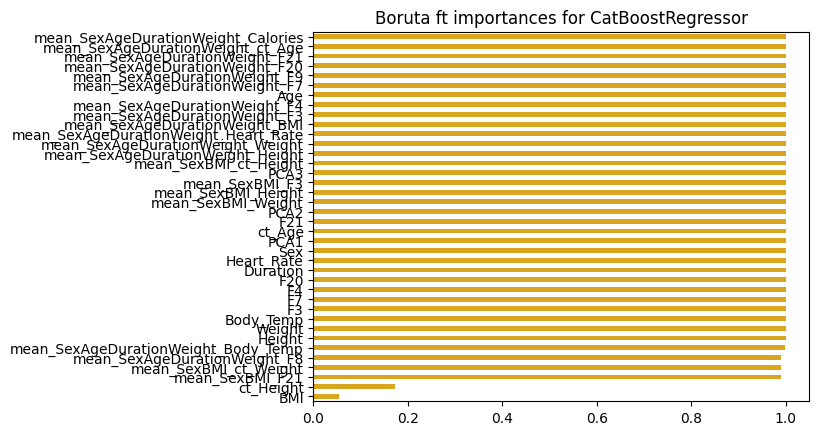

In [14]:
# calculate ft importances
importances = boruta(X, y, deepcopy(E), seed=10, plot=True, alpha=0.95, iterations=10)

__Features overview__

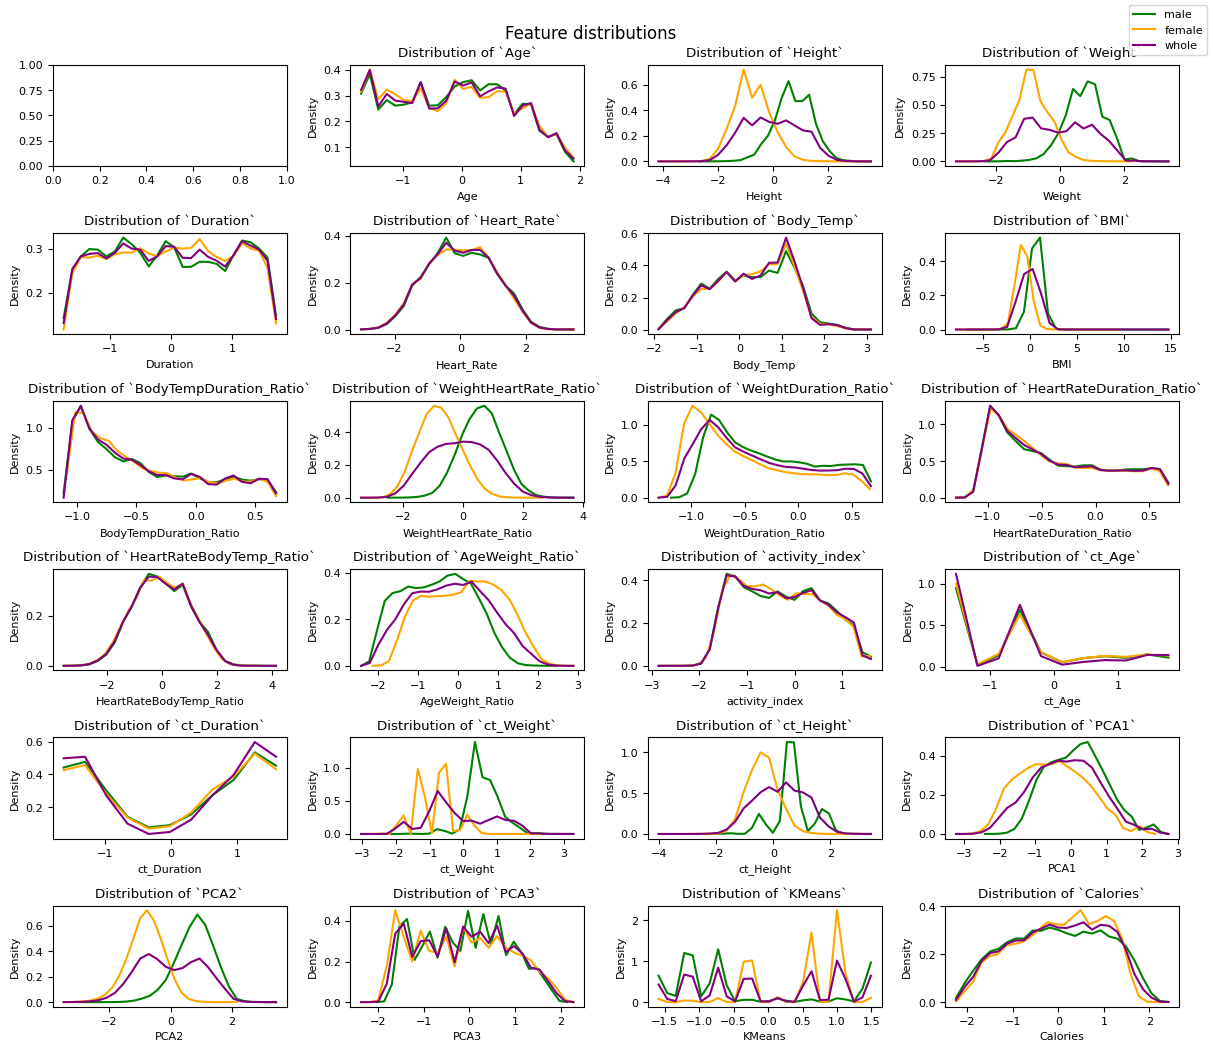

In [21]:
data = X.copy()
# scaler = pre.PowerTransformer()
# data[TARGET] = scaler.fit_transform(y.to_numpy().reshape(-1, 1))
data[TARGET] = y

COLUMNS = 4
ROWS = np.ceil(len(data.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')

MALE = data.Sex > 0.5
for n, feature in enumerate(data.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'Sex':
        # feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')
        ...
    elif feature.startswith('ct_'):
        bins = data[feature].unique().size
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=bins, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=bins, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=bins, color='purple')
    else:
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=25, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=25, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')

fig.legend(['male', 'female', 'whole'])
plt.show()

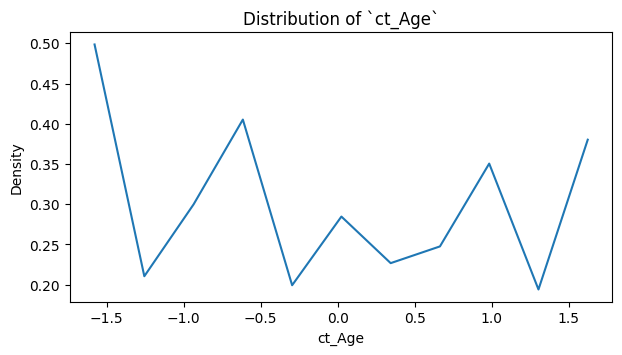

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
values = X.ct_Age
# values = (df.Weight / df.Height) ** np.log(df.Heart_Rate / df.Duration)
# values = np.log((df.Heart_Rate * df.Body_Temp * df.Duration * df.Age) ** (df.Weight / df.Height))
feature_overview(ax, values, FigureType.DENSITY)
plt.show()

__Correlations__

In [24]:
# THRESHOLD = 0.0

# data = X.copy()
# labels = data.columns
# data[TARGET] = y

# CORRELATIONS = ('pearson', 'spearman', 'kendall')
# # CORRELATIONS = ('pearson', )
# # drawing
# fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 4.5), sharex=True)
# fig.set_layout_engine('compressed')
# fig.suptitle('Correlations')
# for n, method in enumerate(CORRELATIONS):
#     ax = axes[n] if len(CORRELATIONS) > 1 else axes
#     ax.set_title(method.capitalize())
#     target_corr = data.corr(method)[[TARGET]].drop(TARGET).sort_values(TARGET, ascending=False)
#     values = target_corr.values.squeeze()
#     filtered = (abs(values) > THRESHOLD)
#     ax.imshow(values[filtered].reshape(1, -1), cmap='Blues')
#     ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
#     ax.set_yticks([0], labels=[TARGET])
# plt.show()

__Final fit__

In [ ]:
E = SGDRegressor(
    learning_rate='adaptive',
    eta0=0.005,
    # alpha=0.001,
    max_iter=15000,
    random_state=19,
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
sgd = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.06850; | VALID RMSLE=0.06913


In [8]:
E = XGBRegressor(  # see more https://xgboost.readthedocs.io/en/stable/parameter.html
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    random_state=23,
    verbosity=0,
    device='cuda'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
xgb = model = E.fit(X, y)

# E = XGBRegressor(  # see more https://xgboost.readthedocs.io/en/stable/parameter.html
#     n_estimators=3500,
#     learning_rate=0.05,
#     max_depth=5,
#     random_state=23,
#     verbosity=0,
#     device='cuda'
# )
# _ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
# xgb = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05134; | VALID RMSLE=0.06009
Fold: 1; TRAIN RMSLE=0.05124; | VALID RMSLE=0.05949
Fold: 2; TRAIN RMSLE=0.05120; | VALID RMSLE=0.05952
MEAN: TRAIN RMSLE=0.05126; | VALID RMSLE=0.05970


In [15]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='cuda'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
lgbm = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05323; | VALID RMSLE=0.06094
Fold: 1; TRAIN RMSLE=0.05323; | VALID RMSLE=0.06026
Fold: 2; TRAIN RMSLE=0.05322; | VALID RMSLE=0.06014
MEAN: TRAIN RMSLE=0.05323; | VALID RMSLE=0.06045


In [12]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
catboost = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05589; | VALID RMSLE=0.06039
Fold: 1; TRAIN RMSLE=0.05584; | VALID RMSLE=0.05954
Fold: 2; TRAIN RMSLE=0.05580; | VALID RMSLE=0.05987
MEAN: TRAIN RMSLE=0.05584; | VALID RMSLE=0.05993


In [ ]:
# E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
#     n_estimators=2500,
#     learning_rate=0.2,
#     max_depth=4,
#     random_state=23,
#     silent=True,
#     allow_writing_files=False,
#     # task_type='GPU'
# )
# _ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
# catboost = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05519; | VALID RMSLE=0.05997
Fold: 1; TRAIN RMSLE=0.05524; | VALID RMSLE=0.05944
Fold: 2; TRAIN RMSLE=0.05527; | VALID RMSLE=0.05940
MEAN: TRAIN RMSLE=0.05523; | VALID RMSLE=0.05960


__Submission__

In [ ]:
# SGD
T = pipe.transform(test.drop(columns=TARGET))
# values = sgd.predict(T)
values = np.clip(y_pipe.inverse_transform(sgd.predict(T).reshape(-1, 1))[:, 0], 1, None)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

c61aa90404414c9ba9bfa099c13b9951


In [7]:
# XGB
T = pipe.transform(test.drop(columns=TARGET))
# values = xgb.predict(T)
values = np.clip(y_pipe.inverse_transform(xgb.predict(T).reshape(-1, 1))[:, 0], 1, None)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

d7480ab44bf24c6ebdf0a9f30c8746e0


In [ ]:
# LGBM
T = pipe.transform(test.drop(columns=TARGET))
# values = lgbm.predict(T)
values = np.clip(y_pipe.inverse_transform(lgbm.predict(T).reshape(-1, 1))[:, 0], 1, None)     # type: ignore

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

524211eebf414beb89d0d25300c42a03


In [13]:
# CatBoost
T = pipe.transform(test.drop(columns=TARGET))
# values = catboost.predict(T)
values = np.clip(y_pipe.inverse_transform(catboost.predict(T).reshape(-1, 1))[:, 0], 1, None)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

549d9315c2e743b8b79ddfcee2a36e62


In [ ]:
#